### Diabetes Risk Factor Analysis - Updated for New Dataset

In [2]:
# 1. Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
import statsmodels.api as sm

In [4]:
# 2. Load dataset
df = pd.read_csv("C:\\Users\\Trupti\\OneDrive\\Desktop\\diabetes_risk_factors_new.csv")
df

,Age,Gender,Area_of_Residence,Education_Level,Income,Height_cm,Weight_kg,Waist_Circumference_cm,Family_History_Diabetes,Blood_Pressure,...,Physical_Activity,Diet_Pattern,Smoking,Alcohol,Sleep_Hours,Stress_Level,Awareness_Testing,BMI,diabetes_status,Glucose
0,58,Male,Rural,Primary,21371,171,108,86,1,Prehypertension,...,Low,Healthy,1,0,9,Medium,1,36.93,Diabetic,117
1,71,Male,Rural,Graduate,7049,155,93,113,1,Prehypertension,...,Moderate,Healthy,0,1,5,Low,1,38.71,Diabetic,107
2,48,Male,Rural,Graduate,36616,164,80,76,1,Hypertension,...,High,Moderate,0,1,6,High,1,29.74,Diabetic,119
3,34,Male,Rural,Secondary,25932,186,68,68,1,Prehypertension,...,Low,Healthy,1,0,5,Medium,1,19.66,Diabetic,132
4,62,Male,Rural,Postgraduate,34855,182,67,92,1,Prehypertension,...,Moderate,Unhealthy,0,1,5,High,0,20.23,Diabetic,106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,79,Male,Urban,Graduate,57921,185,104,70,0,Prehypertension,...,High,Moderate,0,1,6,Low,0,30.39,Diabetic,114
116,79,Female,Urban,Postgraduate,54726,159,94,110,0,Hypertension,...,Low,Moderate,1,0,8,High,1,37.18,Diabetic,109
117,64,Male,Urban,Postgraduate,55300,186,72,98,0,Hypertension,...,High,Moderate,1,1,4,Low,1,20.81,Non-Diabetic,92
118,60,Female,Urban,Secondary,27677,158,85,97,1,Normal,...,High,Healthy,1,1,4,Medium,1,34.05,Diabetic,127


In [6]:
# Convert target variable to binary (1 = Diabetic, 0 = Non-Diabetic)
df["Diabetes"] = df["diabetes_status"].apply(lambda x: 1 if x.strip().lower()=="diabetic" else 0)
df

,Age,Gender,Area_of_Residence,Education_Level,Income,Height_cm,Weight_kg,Waist_Circumference_cm,Family_History_Diabetes,Blood_Pressure,...,Diet_Pattern,Smoking,Alcohol,Sleep_Hours,Stress_Level,Awareness_Testing,BMI,diabetes_status,Glucose,Diabetes
0,58,Male,Rural,Primary,21371,171,108,86,1,Prehypertension,...,Healthy,1,0,9,Medium,1,36.93,Diabetic,117,1
1,71,Male,Rural,Graduate,7049,155,93,113,1,Prehypertension,...,Healthy,0,1,5,Low,1,38.71,Diabetic,107,1
2,48,Male,Rural,Graduate,36616,164,80,76,1,Hypertension,...,Moderate,0,1,6,High,1,29.74,Diabetic,119,1
3,34,Male,Rural,Secondary,25932,186,68,68,1,Prehypertension,...,Healthy,1,0,5,Medium,1,19.66,Diabetic,132,1
4,62,Male,Rural,Postgraduate,34855,182,67,92,1,Prehypertension,...,Unhealthy,0,1,5,High,0,20.23,Diabetic,106,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,79,Male,Urban,Graduate,57921,185,104,70,0,Prehypertension,...,Moderate,0,1,6,Low,0,30.39,Diabetic,114,1
116,79,Female,Urban,Postgraduate,54726,159,94,110,0,Hypertension,...,Moderate,1,0,8,High,1,37.18,Diabetic,109,1
117,64,Male,Urban,Postgraduate,55300,186,72,98,0,Hypertension,...,Moderate,1,1,4,Low,1,20.81,Non-Diabetic,92,0
118,60,Female,Urban,Secondary,27677,158,85,97,1,Normal,...,Healthy,1,1,4,Medium,1,34.05,Diabetic,127,1


In [7]:
# 3. Basic data check
print("Shape of dataset:", df.shape)
print(df.head())
print(df.info())
print(df["Diabetes"].value_counts())

Shape of dataset: (120, 24)
   Age Gender Area_of_Residence Education_Level  Income  Height_cm  Weight_kg  \
0   58   Male             Rural         Primary   21371        171        108   
1   71   Male             Rural        Graduate    7049        155         93   
2   48   Male             Rural        Graduate   36616        164         80   
3   34   Male             Rural       Secondary   25932        186         68   
4   62   Male             Rural    Postgraduate   34855        182         67   

   Waist_Circumference_cm  Family_History_Diabetes   Blood_Pressure  ...  \
0                      86                        1  Prehypertension  ...   
1                     113                        1  Prehypertension  ...   
2                      76                        1     Hypertension  ...   
3                      68                        1  Prehypertension  ...   
4                      92                        1  Prehypertension  ...   

  Diet_Pattern Smoking  Alco

### Exploratory Data Analysis (EDA)

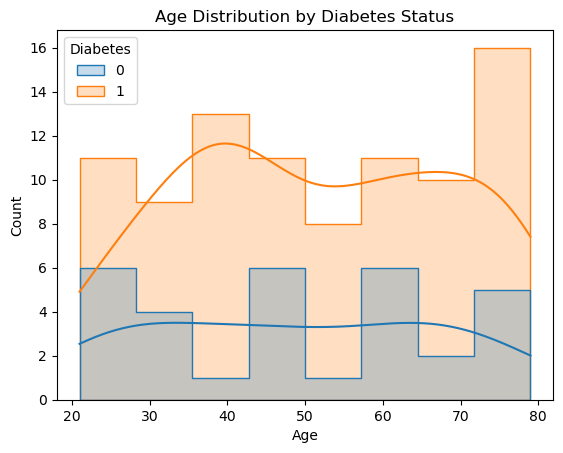

In [8]:
# Histogram of Age
sns.histplot(data=df, x="Age", hue="Diabetes", kde=True, element="step")
plt.title("Age Distribution by Diabetes Status")
plt.show()


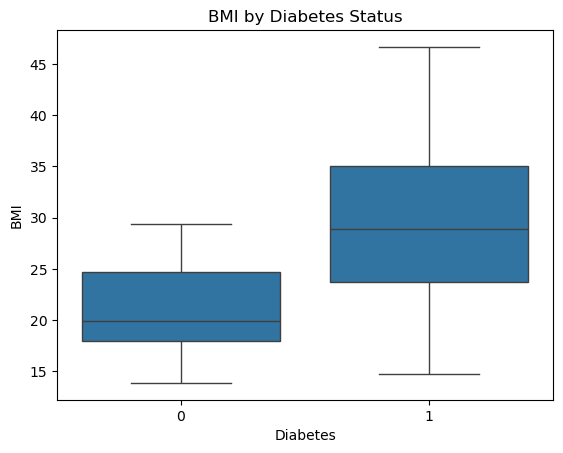

In [9]:
# Boxplot of BMI
sns.boxplot(data=df, x="Diabetes", y="BMI")
plt.title("BMI by Diabetes Status")
plt.show()

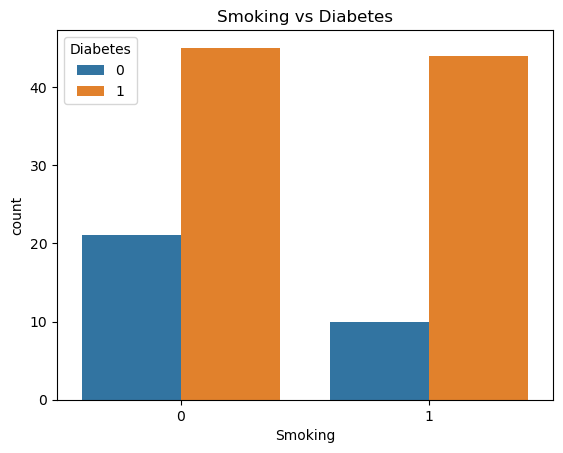

In [10]:
# Bar plot of Smoking Status
sns.countplot(data=df, x="Smoking", hue="Diabetes")
plt.title("Smoking vs Diabetes")
plt.show()

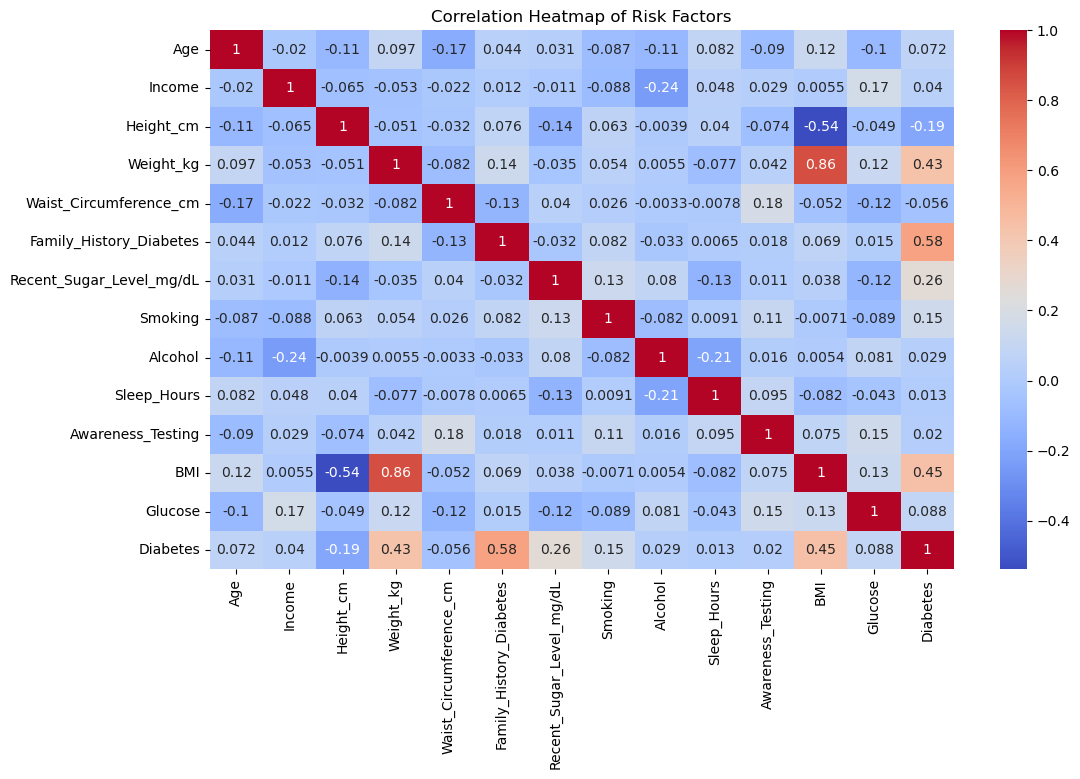

In [11]:
# Correlation heatmap (numeric only)
plt.figure(figsize=(12,7))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Risk Factors")
plt.show()

### Statistical Tests

In [12]:
# Example: Chi-square test (Smoking vs Diabetes)
contingency = pd.crosstab(df["Smoking"], df["Diabetes"])
chi2, p, dof, expected = chi2_contingency(contingency)
print("Chi-square test: Smoking vs Diabetes")
print("Chi2 =", chi2, "p-value =", p)


Chi-square test: Smoking vs Diabetes
Chi2 = 2.0916669412501236 p-value = 0.14810439189149022


In [13]:
# Example: t-test for Age (diabetic vs non-diabetic)
group1 = df[df["Diabetes"]==1]["Age"]
group0 = df[df["Diabetes"]==0]["Age"]
tstat, pval = ttest_ind(group1, group0)
print("T-test for Age:", "t =", tstat, "p =", pval)

T-test for Age: t = 0.7802918887683556 p = 0.43678150937771243


### Logistic Regression (statsmodels)

In [14]:
# Choose predictors (numeric only for now)
predictors = ["Age", "BMI", "Glucose", "Family_History_Diabetes", "Smoking", "Alcohol"]
X = df[predictors]
X = sm.add_constant(X)  # add intercept
y = df["Diabetes"]

logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

         Current function value: 0.203540
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:               Diabetes   No. Observations:                  120
Model:                          Logit   Df Residuals:                      113
Method:                           MLE   Df Model:                            6
Date:                Sun, 28 Sep 2025   Pseudo R-squ.:                  0.6437
Time:                        13:11:32   Log-Likelihood:                -24.425
converged:                      False   LL-Null:                       -68.557
Covariance Type:            nonrobust   LLR p-value:                 6.948e-17
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -7.4006      3.550     -2.085      0.037     -14.359      -0.442
Age                       

C:\Users\Trupti\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [15]:
# Odds Ratios
params = logit_model.params
conf = logit_model.conf_int()
odds_ratios = pd.DataFrame({
    "OR": np.exp(params),
    "CI_low": np.exp(conf[0]),
    "CI_high": np.exp(conf[1])
})
print("\nOdds Ratios:\n", odds_ratios)


Odds Ratios:
                                    OR        CI_low   CI_high
const                    6.109151e-04  5.807990e-07  0.642593
Age                      1.002324e+00  9.626922e-01  1.043587
BMI                      1.308645e+00  1.145702e+00  1.494761
Glucose                  9.992467e-01  9.437837e-01  1.057969
Family_History_Diabetes  1.260309e+12  0.000000e+00       inf
Smoking                  2.009017e+00  4.644031e-01  8.691044
Alcohol                  9.689251e-01  2.161640e-01  4.343071


C:\Users\Trupti\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Random Forest Feature Importance

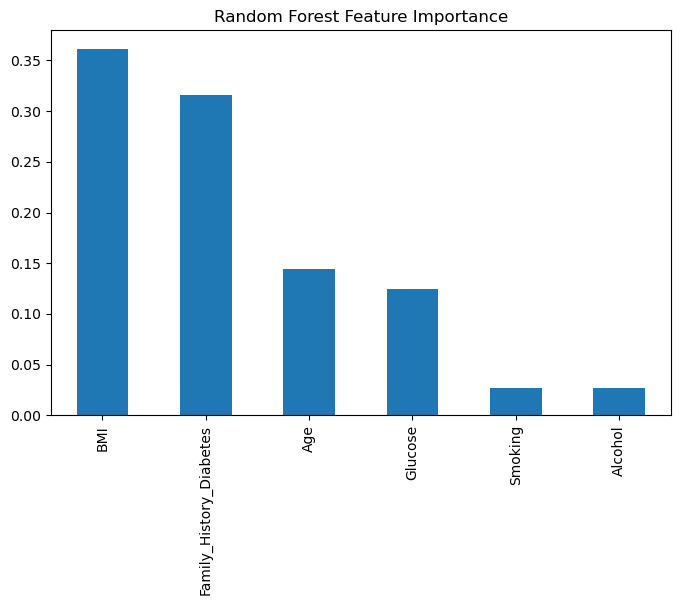

In [16]:
X_ml = df[predictors]
y_ml = df["Diabetes"]

rf = RandomForestClassifier(random_state=42)
rf.fit(X_ml, y_ml)

importances = pd.Series(rf.feature_importances_, index=X_ml.columns).sort_values(ascending=False)
importances.plot(kind="bar", figsize=(8,5))
plt.title("Random Forest Feature Importance")
plt.show()

### ROC Curve

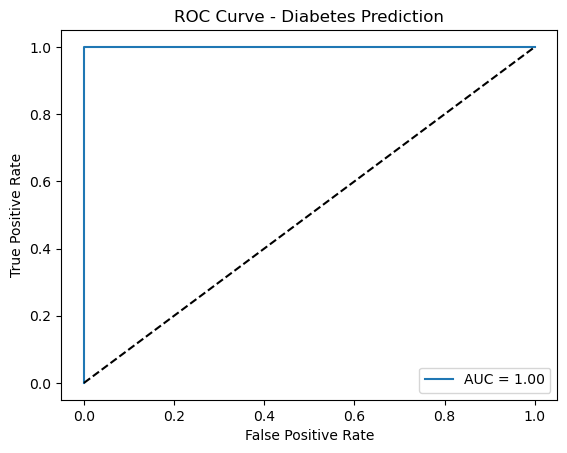

In [17]:
y_prob = rf.predict_proba(X_ml)[:,1]
fpr, tpr, _ = roc_curve(y_ml, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Diabetes Prediction")
plt.legend()
plt.show()

### Rural vs Urban Analysis (Area_of_Residence)

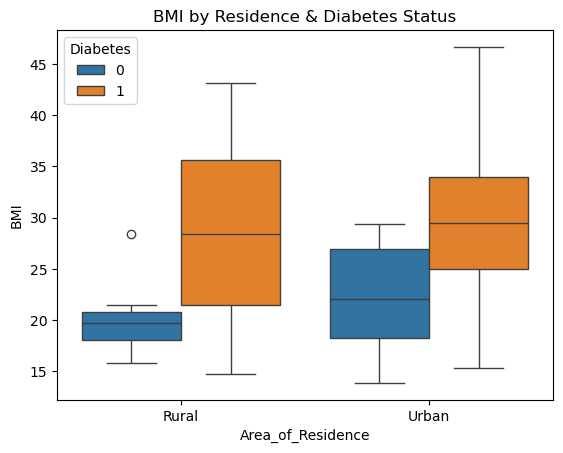

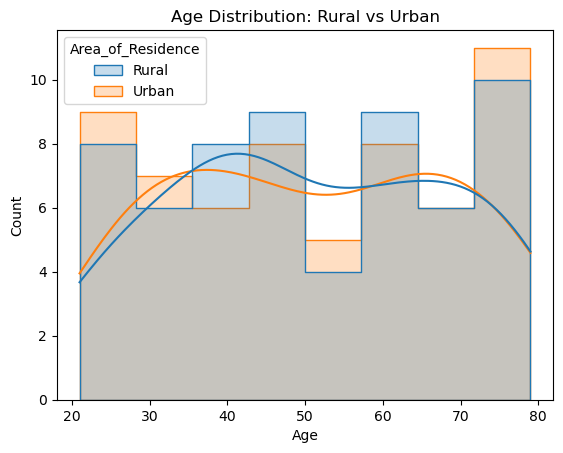

In [18]:
sns.boxplot(data=df, x="Area_of_Residence", y="BMI", hue="Diabetes")
plt.title("BMI by Residence & Diabetes Status")
plt.show()

sns.histplot(data=df, x="Age", hue="Area_of_Residence", kde=True, element="step")
plt.title("Age Distribution: Rural vs Urban")
plt.show()